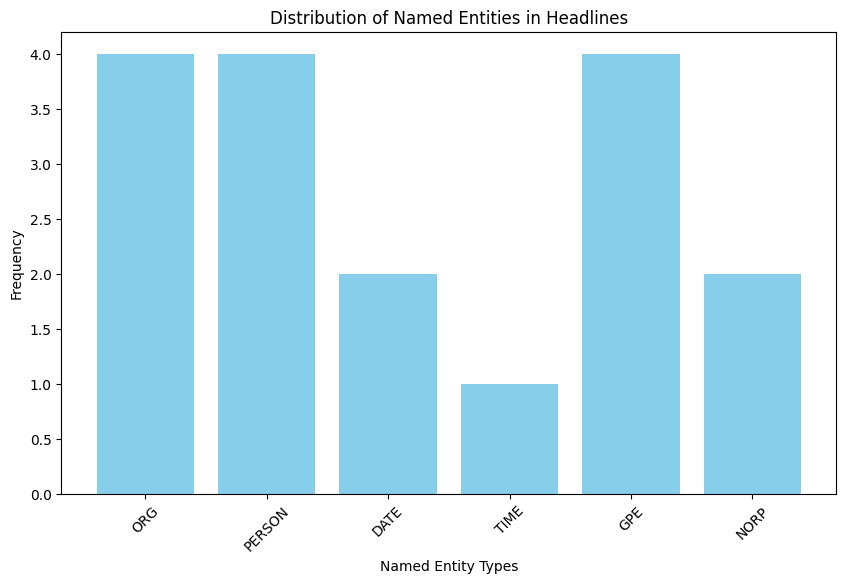

/usr/local/lib/python3.11/dist-packages/spacy/displacy/__init__.py:213: UserWarning: [W006] No entities to visualize found in Doc object. If this is surprising to you, make sure the Doc was processed using a model that supports named entity recognition, and check the `doc.ents` property manually if necessary.
  warnings.warn(Warnings.W006)


In [ ]:
## Run this in Kaggle notebook otherwise dependencies will be the issue

import pandas as pd
import spacy
from collections import Counter
import matplotlib.pyplot as plt
from spacy import displacy

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

# Read the JSON file into a DataFrame
data = pd.read_json("Sarcasm_Headlines_Dataset.json", lines=True)


# Function to extract named entities from headlines
def extract_entities(headlines):
    """
    Function to extract named entities from headlines.

    Args:
    - headlines: List of headlines.

    Returns:
    - List of named entity labels.
    """
    # Initialize a list to store named entity labels
    entity_labels = []

    # Process each headline and extract named entities
    for headline in headlines:
        doc = nlp(headline)
        entities = [ent.label_ for ent in doc.ents]  # NER
        entity_labels.extend(entities)

    return entity_labels


# Function to create a distribution graph of named entities
def entity_distribution(entity_labels):
    """
    Function to create a distribution graph of named entities.

    Args:
    - entity_labels: List of named entity labels.

    Returns:
    - None
    """
    # Initialize a Counter to store the frequency of each named entity
    entity_counter = Counter(entity_labels)

    # Extract entity labels and their frequencies
    labels, frequencies = zip(*entity_counter.items())

    # Plot distribution graph
    plt.figure(figsize=(10, 6))
    plt.bar(labels, frequencies, color="skyblue")
    plt.xlabel("Named Entity Types")
    plt.ylabel("Frequency")
    plt.title("Distribution of Named Entities in Headlines")
    plt.xticks(rotation=45)
    plt.show()


# Function to visualize entities in headlines using displaCy
def visualize_entities(headlines):
    """
    Function to visualize entities in headlines using spaCy's displaCy.

    Args:
    - headlines: List of headlines.

    Returns:
    - None
    """
    for headline in headlines:
        # Process headline text with spaCy
        doc = nlp(headline)

        # Render visualization of entities using displaCy
        displacy.render(doc, style="ent", jupyter=True)


# Extract headlines from the DataFrame
headlines = data["headline"][:30].tolist()

# Extract named entities from headlines
entity_labels = extract_entities(headlines)

# Create distribution graph of named entities
entity_distribution(entity_labels)

# Visualize entities in the headlines
visualize_entities(headlines)

In [ ]:
spacy.explain("NORP")

'Nationalities or religious or political groups'

Synsets, short for "synonym sets," are fundamental concepts in lexical semantics and are specifically associated with WordNet, a lexical database of the English language. Here’s a detailed explanation of synsets and their significance:

What are Synsets?
Definition:

Synset: A synset is a collection of synonym words (lemmas) that express a distinct concept. In other words, it groups together words that are synonymous or closely related in meaning.
Example: In WordNet, the synset for the word "car" might include synonyms like "automobile," "motorcar," and "vehicle," among others.
Structure in WordNet:

Each synset is organized in a hierarchical structure within WordNet.
Hypernym: A synset can have broader concepts known as hypernyms. For instance, "car" is a hypernym of "sedan."
Hyponym: Conversely, a synset may contain more specific terms known as hyponyms. For example, "sedan" is a hyponym of "car."
Attributes and Relationships:

Synsets in WordNet not only provide synonymy relationships but also capture various semantic relationships such as antonymy, meronymy (part-whole relationships), and entailment (logical implication).
This structured organization helps in understanding semantic similarities and differences between words and concepts.

In [ ]:
from itertools import combinations
from collections import defaultdict  # Import defaultdict
import nltk
from nltk.corpus import wordnet as wn  # Import wordnet as wn

# Download WordNet data if not already downloaded
try:
    wn.synsets("test")  # Check if wordnet is available
except LookupError:
    nltk.download("wordnet")


def find_semantic_relationships(headlines):
    """
    Function to extract semantic relationships for word pairs in headlines.

    Args:
    - headlines: List of headlines.

    Returns:
    - Dictionary mapping each word pair to its semantic relationships.
    """
    semantic_relationships = defaultdict(lambda: defaultdict(set))

    # Process each headline
    for headline in headlines:
        print(f"Processing headline: {headline}")
        doc = nlp(headline)

        # Get all unique pairs of words in the headline
        words = [token.text.lower() for token in doc if token.is_alpha]
        pairs = combinations(words, 2)

        # Check relationships between each pair
        for word1, word2 in pairs:
            # Add a check to ensure words have synsets before proceeding
            if not wn.synsets(word1) or not wn.synsets(word2):
                continue  # Skip if either word doesn't have synsets

            synsets1 = wn.synsets(word1)
            synsets2 = wn.synsets(word2)

            for syn1 in synsets1:
                for syn2 in synsets2:
                    # Extract synonyms
                    if syn1 == syn2:
                        semantic_relationships[(word1, word2)]["synonyms"].add(word2)

                    # Extract antonyms
                    for lemma in syn1.lemmas():
                        if word2 in [ant.name() for ant in lemma.antonyms()]:
                            semantic_relationships[(word1, word2)]["antonyms"].add(
                                word2
                            )

                    # Extract hyponyms and hypernyms
                    if syn2 in syn1.hyponyms():
                        semantic_relationships[(word1, word2)]["hyponyms"].add(word2)
                    if syn2 in syn1.hypernyms():
                        semantic_relationships[(word1, word2)]["hypernyms"].add(word2)

                    # Extract meronyms and holonyms
                    if syn2 in syn1.part_meronyms():
                        semantic_relationships[(word1, word2)]["meronyms"].add(word2)
                    if syn2 in syn1.part_holonyms():
                        semantic_relationships[(word1, word2)]["holonyms"].add(word2)

    return semantic_relationships


# Function to display semantic relationships
def display_relationships(semantic_relationships):
    """
    Function to display semantic relationships.

    Args:
    - semantic_relationships: Dictionary mapping word pairs to their semantic relationships.

    Returns:
    - None
    """
    for (word1, word2), relations in semantic_relationships.items():
        print(f"\nWord Pair: ({word1}, {word2})")
        if relations["synonyms"]:
            print(f"  Synonyms: {', '.join(relations['synonyms'])}")
        if relations["antonyms"]:
            print(f"  Antonyms: {', '.join(relations['antonyms'])}")
        if relations["hyponyms"]:
            print(f"  Hyponyms: {', '.join(relations['hyponyms'])}")
        if relations["hypernyms"]:
            print(f"  Hypernyms: {', '.join(relations['hypernyms'])}")
        if relations["meronyms"]:
            print(f"  Meronyms: {', '.join(relations['meronyms'])}")
        if relations["holonyms"]:
            print(f"  Holonyms: {', '.join(relations['holonyms'])}")


# Extract headlines from the DataFrame
# Assuming 'headlines' is already defined from a previous cell execution

# Extract semantic relationships for words in headlines
semantic_relationships = find_semantic_relationships(headlines)

# Display the semantic relationships
display_relationships(semantic_relationships)

Processing headline: former versace store clerk sues over secret 'black code' for minority shoppers
Processing headline: the 'roseanne' revival catches up to our thorny political mood, for better and worse
Processing headline: mom starting to fear son's web series closest thing she will have to grandchild
Processing headline: boehner just wants wife to listen, not come up with alternative debt-reduction ideas
Processing headline: j.k. rowling wishes snape happy birthday in the most magical way
Processing headline: advancing the world's women
Processing headline: the fascinating case for eating lab-grown meat
Processing headline: this ceo will send your kids to school, if you work for his company
Processing headline: top snake handler leaves sinking huckabee campaign
Processing headline: friday's morning email: inside trump's presser for the ages
Processing headline: airline passengers tackle man who rushes cockpit in bomb threat
Processing headline: facebook reportedly working on healt

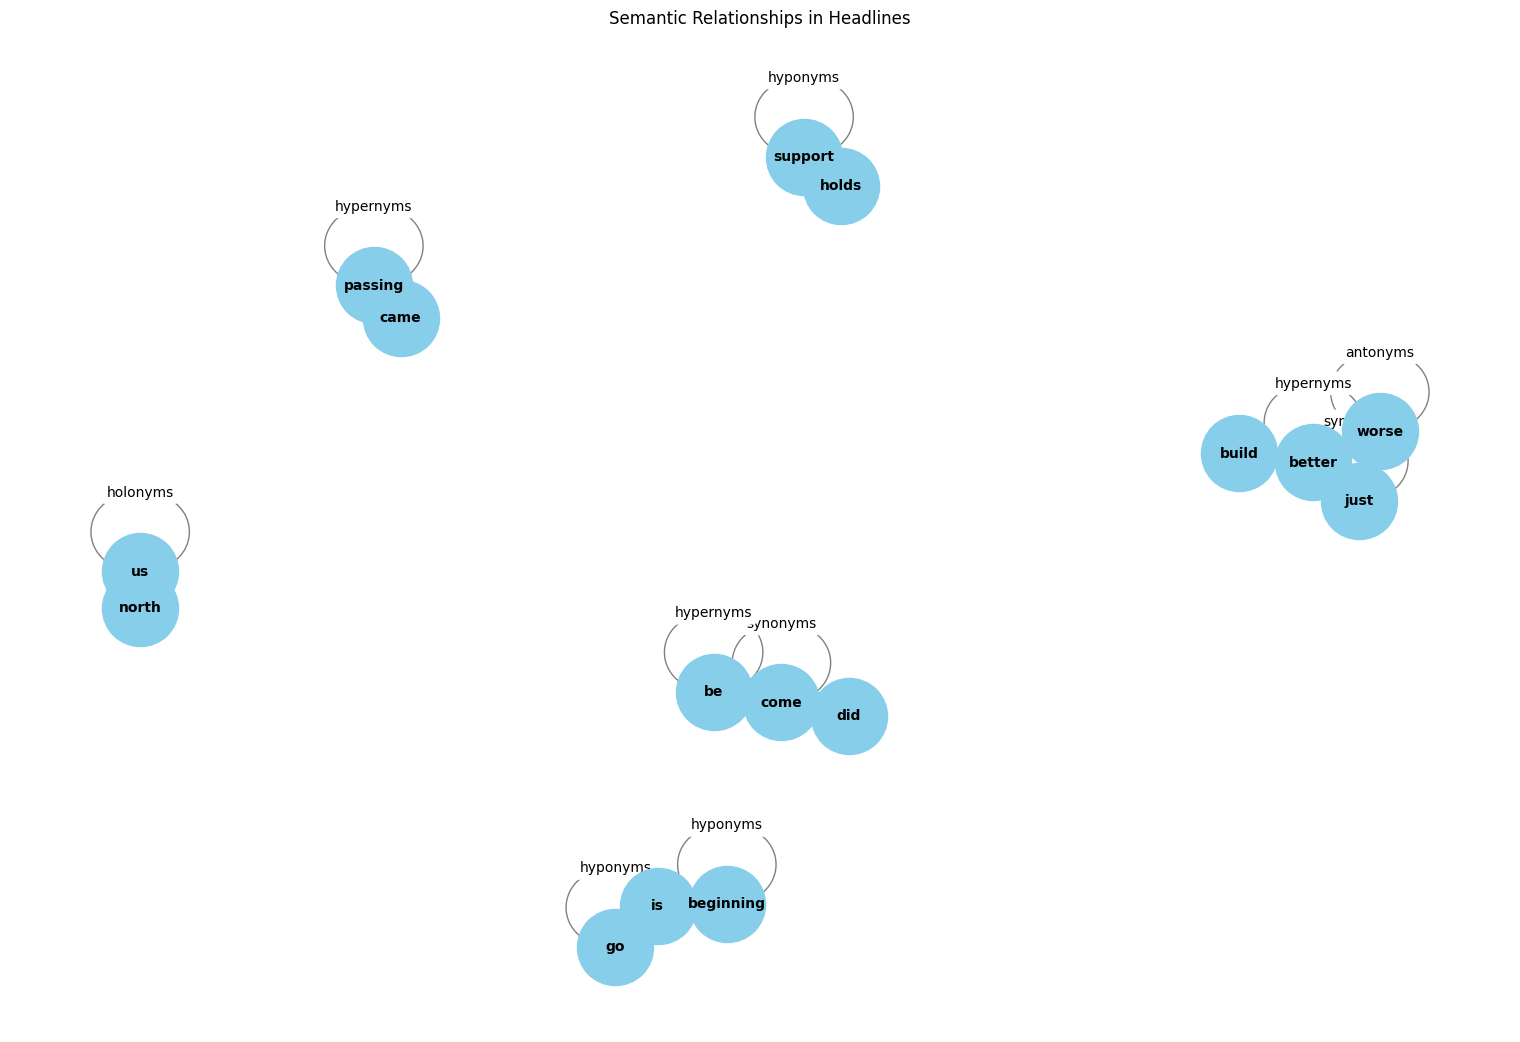

In [ ]:
import pandas as pd
import spacy
from collections import defaultdict
from nltk.corpus import wordnet as wn
import nltk
from itertools import combinations
import networkx as nx
import matplotlib.pyplot as plt


# Function to create a network graph of semantic relationships
def create_graph(semantic_relationships):
    """
    Function to create a network graph of semantic relationships.

    Args:
    - semantic_relationships: Dictionary mapping word pairs to their semantic relationships.

    Returns:
    - None
    """
    G = nx.Graph()

    # Add nodes and edges for each semantic relationship
    for (word1, word2), relations in semantic_relationships.items():
        G.add_node(word1)
        G.add_node(word2)
        for rel_type, words in relations.items():
            for word in words:
                G.add_edge(word1, word, relationship=rel_type)
                G.add_edge(word2, word, relationship=rel_type)

    # Draw the graph
    plt.figure(figsize=(15, 10))
    pos = nx.spring_layout(G, seed=42)  # Set seed for reproducibility
    nx.draw(
        G,
        pos,
        with_labels=True,
        font_size=10,
        node_size=3000,
        node_color="skyblue",
        edge_color="gray",
        font_weight="bold",
    )
    edge_labels = nx.get_edge_attributes(G, "relationship")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
    plt.title("Semantic Relationships in Headlines")
    plt.show()


# Create a network graph of semantic relationships
create_graph(semantic_relationships)

In [ ]:
import pandas as pd
from nltk.corpus import wordnet as wn
import nltk
from spacy.lang.en import STOP_WORDS

# Download WordNet data
nltk.download("wordnet")


# Function to find words causing ambiguity due to multiple senses
def find_ambiguous_words(headlines):
    """
    Function to find words causing ambiguity due to multiple senses.

    Args:
    - headlines: List of headlines.

    Returns:
    - Set of words causing ambiguity.
    """
    ambiguous_words = set()

    # Process each headline
    for headline in headlines:
        # Tokenize the headline and remove stop words
        tokens = [
            token.lower()
            for token in headline.split()
            if token.lower() not in STOP_WORDS
        ]

        # Check each token for multiple senses in WordNet
        for token in tokens:
            synsets = wn.synsets(token)
            if len(synsets) > 1:
                ambiguous_words.add(token)

    return ambiguous_words


ambiguous_words = find_ambiguous_words(headlines)

# Print words causing ambiguity
print("Words causing ambiguity due to multiple senses:", ambiguous_words)

Words causing ambiguity due to multiple senses: {'circus', 'women', 'tackle', 'musical', 'thing', 'man', 'veterans', 'drilling', 'birthday', 'closest', 'catches', 'decision', 'remembrance', 'clerk', 'influences', 'wishes', 'sues', 'drugged', 'working', 'send', 'team', 'protest', 'assures', 'sketch', 'hits', 'happy', 'advancing', 'recommends', 'fear', 'worse', 'rehearsal', 'store', 'campaign', 'stock', 'boar', 'qatar', 'ideas', 'deporting', 'alternative', 'cities', 'carefully', 'visits', 'come', 'inside', 'national', 'fascinating', 'program', 'syrian', 'came', 'woman', 'bigger', 'features', 'work', 'meat', 'dutch', 'sinking', 'honor', 'rushes', 'better', 'lord', 'bush', 'careful', 'raped', 'legal', 'lose', 'whims', 'reported', 'holds', 'support', 'market', 'frightened', 'writers', 'build', 'eating', 'shoppers', 'handler', 'years', 'political', 'north', 'passing', 'leaves', 'company', 'case', 'detonates', 'revival', 'wants', 'trump', 'nation', 'clear', 'reject', 'ago', 'nuclear', 'airlin

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics.pairwise import pairwise_distances


def calculate_similarity(headlines):
    """
    Function to calculate similarity between headlines using TF-IDF and cosine similarity.

    Args:
    - headlines: List of headlines.

    Returns:
    - Similarity matrix between headlines.
    """
    # Initialize TF-IDF vectorizer
    vectorizer = TfidfVectorizer(stop_words="english")

    # Compute TF-IDF matrix for headlines
    tfidf_matrix = vectorizer.fit_transform(headlines)

    # Calculate cosine similarity between headlines
    similarity_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)

    return similarity_matrix


# Calculate similarity between headlines
similarity_matrix = calculate_similarity(headlines)

# Convert similarity matrix to DataFrame for better visualization
similarity_df = pd.DataFrame(similarity_matrix, columns=headlines, index=headlines)

# Display the similarity matrix
print("Similarity between headlines:")
print(similarity_df)

Similarity between headlines:
                                                    former versace store clerk sues over secret 'black code' for minority shoppers  \
former versace store clerk sues over secret 'bl...                                                1.0                                
the 'roseanne' revival catches up to our thorny...                                                0.0                                
mom starting to fear son's web series closest t...                                                0.0                                
boehner just wants wife to listen, not come up ...                                                0.0                                
j.k. rowling wishes snape happy birthday in the...                                                0.0                                
advancing the world's women                                                                       0.0                                
the fascinating case for eating 

In [ ]:
# Select two headlines
headline1 = (
    "former versace store clerk sues over secret 'black code' for minority shoppers"
)
headline2 = "the 'roseanne' revival catches up to our thorny political mood, for better and worse"

# Calculate similarity between the two headlines
similarity_score = similarity_df.loc[headline1, headline2]

print("Similarity score between the two headlines:")
print(f"Headline 1: {headline1}")
print(f"Headline 2: {headline2}")
print(f"Similarity score: {similarity_score:.4f}")

Similarity score between the two headlines:
Headline 1: former versace store clerk sues over secret 'black code' for minority shoppers
Headline 2: the 'roseanne' revival catches up to our thorny political mood, for better and worse
Similarity score: 0.0000


In [ ]:
from gensim.models import Word2Vec
from gensim.models.keyedvectors import KeyedVectors
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np


# Function to train Word2Vec model
def train_word2vec_model(sentences, vector_size=100, window=5, min_count=1, workers=4):
    """
    Function to train a Word2Vec model on a corpus of sentences.

    Args:
    - sentences: List of sentences, where each sentence is represented as a list of words.
    - vector_size: Dimensionality of the word vectors.
    - window: Maximum distance between the current and predicted word within a sentence.
    - min_count: Minimum frequency count of words to consider during training.
    - workers: Number of CPU cores to use for training.

    Returns:
    - Trained Word2Vec model.
    """
    model = Word2Vec(
        sentences,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        workers=workers,
    )
    return model


# Function to calculate sentence vector using Word2Vec model
def calculate_sentence_vector_word2vec(model, sentence):
    """
    Function to calculate the sentence vector using a trained Word2Vec model.

    Args:
    - model: Trained Word2Vec model.
    - sentence: Input sentence represented as a list of words.

    Returns:
    - Sentence vector.
    """
    word_vectors = [
        model.wv[word] for word in sentence if word in model.wv
    ]  # train model -keyed vectors - vector
    if word_vectors:
        return np.mean(word_vectors, axis=0)
    else:
        return np.zeros(model.vector_size)


# Return zero vector if no words are found in the model


# Read the JSON file into a DataFrame
data = pd.read_json(
    "/kaggle/input/sarcasm-dataset/Sarcasm_Headlines_Dataset.json", lines=True
)

# Extract headlines and labels from the DataFrame
headlines = data["headline"]
labels = data["is_sarcastic"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    headlines, labels, test_size=0.2, random_state=42
)

# Train Word2Vec model on training data
word2vec_model = train_word2vec_model(X_train)

# Train logistic regression classifier on Word2Vec sentence vectors
X_train_word2vec = [
    calculate_sentence_vector_word2vec(word2vec_model, sentence) for sentence in X_train
]  # row observation entire sentence at first position, model
classifier_word2vec = LogisticRegression(max_iter=1000)
classifier_word2vec.fit(X_train_word2vec, y_train)


# Predict polarity scores for test data using Word2Vec classifier
X_test_word2vec = [
    calculate_sentence_vector_word2vec(word2vec_model, sentence) for sentence in X_test
]
y_pred_word2vec = classifier_word2vec.predict(X_test_word2vec)


# Evaluate accuracy of Word2Vec classifier
accuracy_word2vec = accuracy_score(y_test, y_pred_word2vec)
print("Accuracy of Word2Vec classifier:", accuracy_word2vec)

Accuracy of Word2Vec classifier: 0.6224260576563085


In [ ]:
# Print some examples of X_test and y_test
for i in range(5):
    print("Example {}: ".format(i + 1))
    print("X_test: ", X_test.iloc[i])
    print("y_test: ", y_test.iloc[i])
    print("y_pred_word2vec", y_pred_word2vec[i])
    print()

Example 1: 
X_test:  isis recruiter excited to be talking to popular high schooler for once
y_test:  1
y_pred_word2vec 0

Example 2: 
X_test:  jimmy fallon could barely keep it together during this cardi b interview
y_test:  0
y_pred_word2vec 0

Example 3: 
X_test:  drunk ron weasley wishing harry potter 'happy birthday' is pure magic
y_test:  0
y_pred_word2vec 0

Example 4: 
X_test:  hoosier hostility: not the american way
y_test:  0
y_pred_word2vec 0

Example 5: 
X_test:  turns out running doesn't wreck your knees after all
y_test:  0
y_pred_word2vec 0

